# Intel GPU加速Whisper识别


## 安装依赖
升级pip
安装torch+xpu及intel-extension-for-pytorch
安装openai-whisper

In [12]:
%pip  install --upgrade pip
%pip  install torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 --index-url https://download.pytorch.org/whl/xpu
%pip  install intel-extension-for-pytorch==2.7.10+xpu --index-url https://pytorch-extension.intel.com/release-whl/stable/xpu/cn/
%pip  install openai-whisper

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/xpu
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pytorch-extension.intel.com/release-whl/stable/xpu/cn/
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.


## 示例代码
模型自动下载
调用本地Intel GPU资源，生成结果带有单词级时间戳
根据时间戳生成SRT格式

In [14]:
import whisper,torch
def format_time(seconds: float) -> str:
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = seconds % 60  # 保留小数部分
    return f"{hours:02}:{minutes:02}:{seconds:06.3f}".replace('.', ',')  # 保留两位小数并替换小数点为逗号
def generate_srt(result):
    srt_output = ""
    for i, segment in enumerate(result['segments']):
        words = segment.get('words', [])
        if not words:
            continue
        print(segment)
        start_time = format_time(segment["words"][0]["start"])
        end_time = format_time(segment["words"][-1]["end"])
        text = segment["text"]
        
        # SRT 格式
        srt_output += f"{i + 1}\n"  # 字幕序号
        srt_output += f"{start_time} --> {end_time}\n"  # 时间戳
        srt_output += f"{text}\n\n"  # 字幕文本

    print(srt_output)
    return srt_output
def recognize_audio(audio_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "xpu" if torch.xpu.is_available() else "cpu")
    print(f'Use devices：{device}')
    model = whisper.load_model("large-v3", download_root="./", device=device)
    result = model.transcribe(audio_path, initial_prompt="将结果转录为简体中文", word_timestamps=True)
    return generate_srt(result)
recognize_audio('./example/ceshi.wav')

Use devices：xpu
{'id': 0, 'seek': 0, 'start': np.float64(1.2800000000000014), 'end': np.float64(4.5), 'text': '小熊的奇幻森林之旅', 'tokens': [50365, 7322, 21805, 232, 1546, 26907, 3509, 119, 16407, 106, 32063, 9574, 4479, 227, 50596], 'temperature': 0.0, 'avg_logprob': -0.2098043646131243, 'compression_ratio': 1.0303030303030303, 'no_speech_prob': 0.039626020938158035, 'words': [{'word': '小', 'start': np.float64(1.2800000000000014), 'end': np.float64(1.84), 'probability': np.float64(0.9735198020935059)}, {'word': '熊', 'start': np.float64(1.84), 'end': np.float64(2.26), 'probability': np.float64(0.9983317852020264)}, {'word': '的', 'start': np.float64(2.26), 'end': np.float64(2.48), 'probability': np.float64(0.996282160282135)}, {'word': '奇', 'start': np.float64(2.48), 'end': np.float64(2.78), 'probability': np.float64(0.9991851449012756)}, {'word': '幻', 'start': np.float64(2.78), 'end': np.float64(3.24), 'probability': np.float64(0.9999898672103882)}, {'word': '森', 'start': np.float64(3.24), 'e

'1\n00:00:01,280 --> 00:00:04,500\n小熊的奇幻森林之旅\n\n2\n00:00:05,880 --> 00:00:07,940\n在一片广袤无垠\n\n3\n00:00:07,940 --> 00:00:10,200\n郁郁葱葱的大森林里\n\n4\n00:00:10,200 --> 00:00:11,980\n住着一只毛毛的小熊\n\n'

## 运行过程中资源使用情况截图
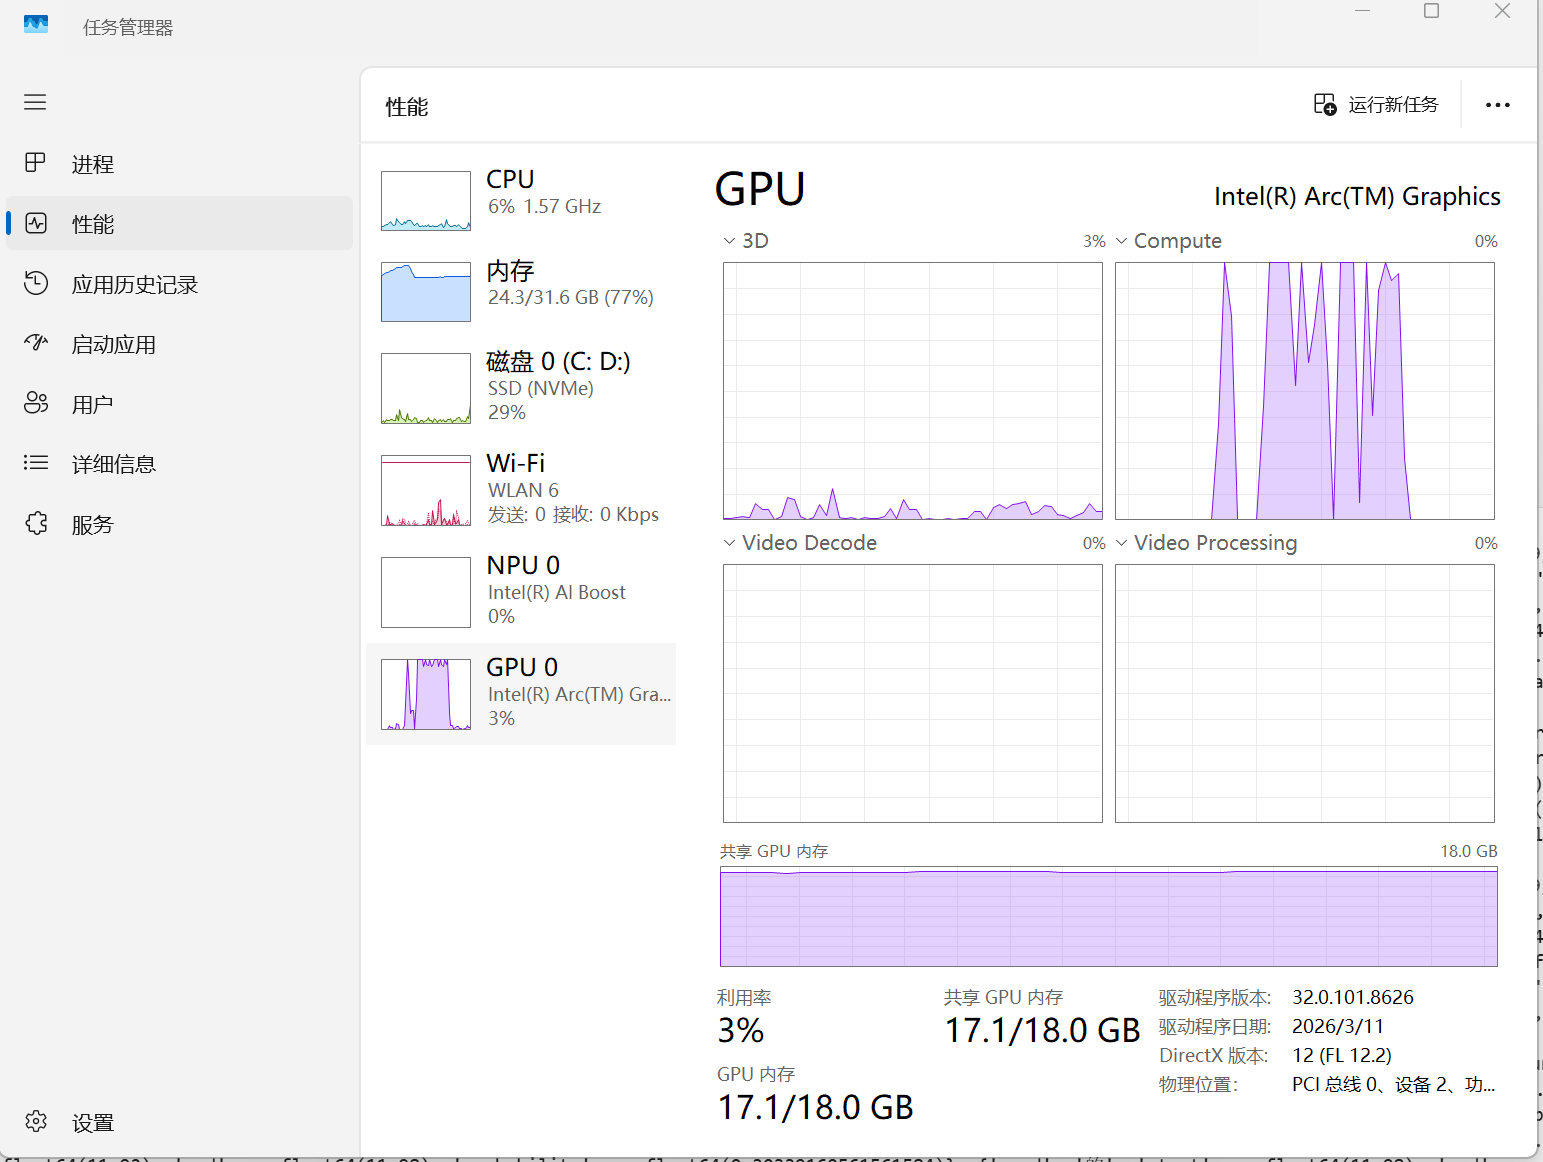